# Stage 2 — Quantum Encoding

### Part of: *Quantum Circuit-Based Adaptation for Credit Risk Analysis*

**Previous:** ← `01_classical_gci_model.ipynb`
**Next:** → `03_circuit_design.ipynb`

---

Stage 1 gave us a purely classical function, PD(z) — a number between 0 and 1. Stage 3 needs an actual quantum gate. This notebook is the bridge between the two: it explains **how a classical probability becomes a rotation angle**, derives the exact numbers needed, and — before any Qiskit circuit exists — proves numerically that the mechanism works.


## 1. What Is Quantum Encoding? (General Overview)

**Quantum encoding** (sometimes called "data loading") is the general problem of representing classical data inside a quantum state, so that measuring the state gives you back something related to that data. There are several standard encoding schemes:

- **Basis encoding** — classical bits are mapped directly onto computational basis states (e.g. the number 5 → the state \|101⟩). Simple, but uses one qubit per bit — no quantum advantage.
- **Amplitude encoding** — an entire classical vector is packed into the amplitudes of a single quantum state (e.g. $n$ qubits can encode $2^n$ numbers). Extremely compact, but the state-preparation circuit is often expensive to build.
- **Angle encoding** — a single classical number is mapped onto the *rotation angle* of a gate, and the resulting **measurement probability** (via the Born rule) is what carries the information. This is what we use here.

**Why angle encoding fits this project:** a single-qubit $R_y(\theta)$ rotation applied to $|0\rangle$ produces

$$
R_y(\theta)\,|0\rangle = \cos(\theta/2)\,|0\rangle + \sin(\theta/2)\,|1\rangle
$$

so the probability of measuring $|1\rangle$ is $\sin^2(\theta/2)$ — a number between 0 and 1, produced automatically by the Born rule, no extra machinery required. If we can find a rotation angle $\theta(z)$ such that $\sin^2(\theta(z)/2) \approx \mathrm{PD}(z)$, then a *single controlled rotation* on a qubit reproduces the classical default probability, for any input $z$.


## 2. Why We Use This Here

1. **PD(z) is already bounded in [0, 1].** It's a probability, so it's a natural fit for angle encoding — no rescaling or ancilla qubits needed, unlike encoding an arbitrary unbounded number.

2. **It matches exactly how the base paper defines the model.** The paper defines the quantum-mapped conditional default probability as $\mathrm{PD}_k(z) \equiv P_1 = \sin^2(\alpha_k z + \beta_k)$ (their Eq. 2) — this notebook derives $\alpha_k$ and $\beta_k$ from first principles, since the paper only references its Supplementary Material for the exact formulas.

3. **It's what makes the asset qubit "conditional."** In Stage 3, the asset qubit's rotation angle won't be a fixed number — it will depend on *which basis state the z-register happens to be in*. Angle encoding is precisely the mechanism that lets a rotation depend on another qubit register's value (via **controlled** rotations), which is exactly the "conditional" in "Gaussian Conditional-Independence."


## 3. Where This Fits in the Project Pipeline

This is **Stage 2 of 9**. Its inputs and outputs:

- **Input:** the PD(z) formula and parameters (p⁰, ρ) from `01_classical_gci_model.ipynb`.
- **Output:** the linear fit parameters $\alpha, \beta$ (continuous z), and their register-adapted versions $\tilde\alpha, \tilde\beta$ (for a discretized z-register of a given qubit count) — these are exactly the numbers `03_circuit_design.ipynb` will plug into controlled-$R_y$ gates.

Nothing quantum-hardware-related happens yet — this is still entirely classical algebra. The only "quantum" part is the *target* we're deriving parameters for (a rotation gate), and a numpy-only simulation at the end that proves the mechanism, without needing Qiskit.


## 4. The Mathematics

### 4.1 The target: PD(z) as a rotation angle

Recall from Stage 1:

$$
\mathrm{PD}(z) = \Phi\!\left( \frac{\Phi^{-1}(p^0) - \sqrt{\rho}\, z}{\sqrt{1-\rho}} \right)
$$

We want to find a rotation angle function $\theta(z)$ such that a qubit rotated by $R_y(2\theta(z))$ has

$$
P(|1\rangle) = \sin^2(\theta(z)) = \mathrm{PD}(z)
$$

(The factor of 2 appears because $R_y(\phi)$ produces $\sin^2(\phi/2)$ — so setting $\phi = 2\theta(z)$ gives $\sin^2(\theta(z))$ directly, matching the paper's convention $R_y(2(\alpha z + \beta))$.)

Solving for $\theta(z)$ exactly:

$$
\theta(z) = \arcsin\!\left(\sqrt{\mathrm{PD}(z)}\right)
$$

This $\theta(z)$ is a perfectly valid — but **nonlinear** — function of $z$. A single qubit rotated by exactly this angle would reproduce PD(z) with zero error. The problem: nonlinear angle functions are awkward to implement on a multi-qubit register (see §4.3), so instead we approximate it.

### 4.2 The linear approximation: PD(z) ≈ sin²(αz + β)

We approximate $\theta(z)$ by a straight line:

$$
\theta(z) \approx \alpha z + \beta
$$

so that

$$
\mathrm{PD}(z) \approx \sin^2(\alpha z + \beta)
$$

**How $\alpha$ (slope) and $\beta$ (offset) are found:** we compute $\theta(z) = \arcsin(\sqrt{\mathrm{PD}(z)})$ at many points across the range of interest (e.g. $z \in [-3, 3]$, covering ±3 standard deviations), then fit a straight line to those points using **ordinary least squares**:

$$
(\alpha, \beta) = \arg\min_{a,b} \sum_i \big(\theta(z_i) - (a z_i + b)\big)^2
$$

This is the standard linear-regression normal-equations problem, solved directly (`numpy.polyfit`, degree 1). Since $\theta(z)$ is nearly linear over a few standard deviations (it's a mild S-curve), the residual error of this fit turns out to be small — we verify this numerically in §5.

### 4.3 From continuous z to a discretized qubit register

The z-register from Stage 1 doesn't represent a continuous $z$ — it represents one of $2^n$ discrete grid points, indexed by an integer $b \in \{0, 1, \dots, 2^n-1\}$ (the qubit register's binary value). Recall Stage 1's affine mapping from index to grid value:

$$
z(b) = -z_{\max} + \frac{2 z_{\max}}{2^n - 1}\, b
$$

Substituting this into $\alpha z + \beta$ and collecting terms gives a new **linear function of the integer $b$ directly**:

$$
\alpha z(b) + \beta = \underbrace{\left(\alpha \cdot \frac{2z_{\max}}{2^n-1}\right)}_{\displaystyle \tilde\alpha} b \;+\; \underbrace{\big(\beta - \alpha z_{\max}\big)}_{\displaystyle \tilde\beta}
$$

This matches the base paper's Eq. (4): $R_y\big(2(\tilde\alpha_k\, \hat z_{\text{code}} + \tilde\beta_k)\big)$, where $\hat z_{\text{code}}$ is exactly our integer $b$. $\tilde\alpha$ and $\tilde\beta$ are what actually get built into the circuit in Stage 3 — they already absorb the discretization grid, so the circuit only ever needs to know the register's raw binary value.

### 4.4 The key trick: encoding a linear function of an $n$-qubit register with only $n+1$ gates

This is the part that makes the whole scheme *hardware-efficient*. Naively, a rotation that depends on the register's value $b$ (which ranges over $2^n$ possibilities) sounds like it needs $2^n$ different controlled operations — one for every possible register state. It doesn't.

**The trick:** any integer $b$ has a unique binary expansion $b = \sum_{k=0}^{n-1} b_k \cdot 2^k$, where $b_k \in \{0,1\}$ is the $k$-th bit. Because $R_y$ rotations about the same axis simply **add their angles** when applied one after another ($R_y(\phi_1)R_y(\phi_2) = R_y(\phi_1+\phi_2)$), we can build $\tilde\alpha\, b + \tilde\beta$ on the asset qubit using:

1. **One unconditional rotation** $R_y(2\tilde\beta)$ — always applied, contributes the offset.
2. **$n$ controlled rotations** — for each register qubit $k$ (which holds bit $b_k$), apply $R_y(2\tilde\alpha \cdot 2^k)$ on the asset qubit, **controlled on register qubit $k$**. This rotation only "fires" (contributes its angle) when $b_k = 1$.

Summing the angles that actually fire, for a register in basis state $b$:

$$
2\tilde\beta + \sum_{k=0}^{n-1} b_k \cdot \big(2\tilde\alpha \cdot 2^k\big) = 2\tilde\beta + 2\tilde\alpha \sum_{k=0}^{n-1} b_k 2^k = 2\big(\tilde\alpha\, b + \tilde\beta\big)
$$

— exactly the target angle, for **every** possible value of $b$ simultaneously (since the register can be in a superposition of all $b$ values, and this construction is linear/superposition-safe). Total gate count: just $n+1$ rotations, regardless of how many basis states ($2^n$) the register spans. This is the "hardware-efficient" part of the ansatz the paper (and this project) relies on.


## 5. Implementation

### 5.1 Fitting α and β


In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# ---- Model parameters, matching Stage 1 exactly ----
p0, rho, z_max = 0.25, 0.027, 3.0

def pd_given_z(z, p0=p0, rho=rho):
    """Classical GCI/Vasicek conditional default probability (from Stage 1)."""
    numerator = norm.ppf(p0) - np.sqrt(rho) * z
    denominator = np.sqrt(1 - rho)
    return norm.cdf(numerator / denominator)

def theta_exact(z):
    """The exact (nonlinear) rotation angle that reproduces PD(z) with zero error."""
    return np.arcsin(np.sqrt(pd_given_z(z)))

# ---- Fit a straight line theta(z) ~ alpha*z + beta via least squares ----
z_fit = np.linspace(-z_max, z_max, 400)
theta_fit_targets = theta_exact(z_fit)

alpha, beta = np.polyfit(z_fit, theta_fit_targets, 1)

print(f"Fitted slope   alpha = {alpha:.6f}")
print(f"Fitted offset  beta  = {beta:.6f}")
print(f"\nApproximation:  PD(z)  ~=  sin^2({alpha:.4f} * z + {beta:.4f})")


Fitted slope   alpha = -0.060489
Fitted offset  beta  = 0.524048

Approximation:  PD(z)  ~=  sin^2(-0.0605 * z + 0.5240)


### 5.2 Validating the linear approximation

How good is this approximation? We compare $\sin^2(\alpha z + \beta)$ against the true PD(z) across the full range, and report the worst-case and average error.


In [2]:
z_test = np.linspace(-z_max, z_max, 400)
pd_true = pd_given_z(z_test)
pd_approx = np.sin(alpha * z_test + beta) ** 2
abs_error = np.abs(pd_approx - pd_true)

print(f"Max absolute error  : {abs_error.max():.5f}  ({abs_error.max()*100:.3f} percentage points)")
print(f"Mean absolute error : {abs_error.mean():.5f}  ({abs_error.mean()*100:.3f} percentage points)")


Max absolute error  : 0.00653  (0.653 percentage points)
Mean absolute error : 0.00248  (0.248 percentage points)


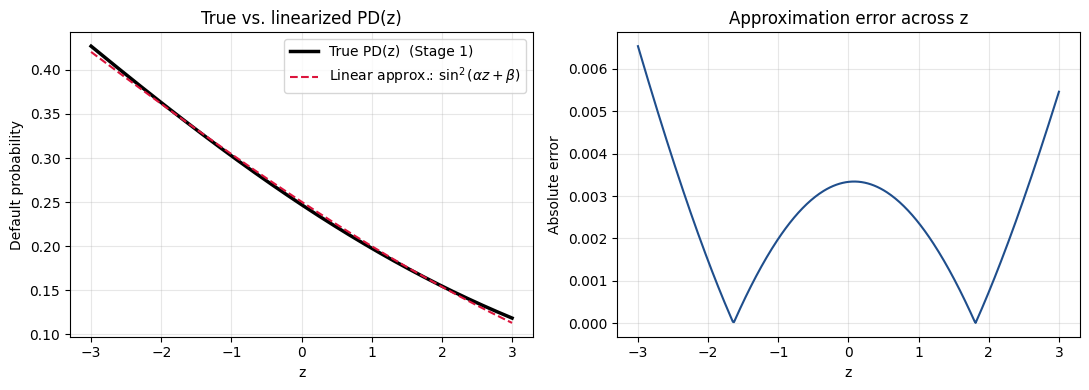

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(z_test, pd_true, color='black', linewidth=2.5, label='True PD(z)  (Stage 1)')
axes[0].plot(z_test, pd_approx, color='crimson', linewidth=1.5, linestyle='--',
             label=r'Linear approx.: $\sin^2(\alpha z + \beta)$')
axes[0].set_xlabel('z'); axes[0].set_ylabel('Default probability')
axes[0].set_title('True vs. linearized PD(z)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(z_test, abs_error, color='#1f4e8c')
axes[1].set_xlabel('z'); axes[1].set_ylabel('Absolute error')
axes[1].set_title('Approximation error across z')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('quantum_encoding_fit_validation.png', dpi=150)
plt.show()


### 5.3 Deriving the register-adapted parameters ($\tilde\alpha$, $\tilde\beta$)

We now fold in the discretization grid from Stage 1, for both the 2-qubit and 3-qubit z-registers, producing $\tilde\alpha$ and $\tilde\beta$ — the numbers that will directly parameterize the controlled-$R_y$ gates in Stage 3.


In [4]:
def discretize_z(n_qubits, z_max=z_max):
    """Same discretization as Stage 1: maps basis index b -> grid point z(b)."""
    n_bins = 2 ** n_qubits
    b = np.arange(n_bins)
    z_grid = -z_max + (2 * z_max) * b / (n_bins - 1)
    return z_grid

def register_adapted_params(n_qubits, alpha=alpha, beta=beta, z_max=z_max):
    """Fold Stage 1's affine grid mapping into alpha, beta -> alpha_tilde, beta_tilde
    (matches the base paper's Eq. 4).
    """
    n_bins = 2 ** n_qubits
    slope = (2 * z_max) / (n_bins - 1)      # from z(b) = -z_max + slope * b
    alpha_tilde = alpha * slope
    beta_tilde = beta - alpha * z_max
    return alpha_tilde, beta_tilde

results = {}
for n_qubits in (2, 3):
    a_tilde, b_tilde = register_adapted_params(n_qubits)
    results[n_qubits] = (a_tilde, b_tilde)
    print(f"--- {n_qubits}-qubit z-register ---")
    print(f"  alpha_tilde = {a_tilde:.6f}")
    print(f"  beta_tilde  = {b_tilde:.6f}")

    # sanity check: alpha_tilde*b + beta_tilde must equal alpha*z(b) + beta for every b
    z_grid = discretize_z(n_qubits)
    lhs = a_tilde * np.arange(2 ** n_qubits) + b_tilde
    rhs = alpha * z_grid + beta
    print(f"  max mismatch vs. alpha*z(b)+beta : {np.max(np.abs(lhs - rhs)):.2e}\n")


--- 2-qubit z-register ---
  alpha_tilde = -0.120979
  beta_tilde  = 0.705516
  max mismatch vs. alpha*z(b)+beta : 5.55e-17

--- 3-qubit z-register ---
  alpha_tilde = -0.051848
  beta_tilde  = 0.705516
  max mismatch vs. alpha*z(b)+beta : 1.11e-16



### 5.4 Proving the binary-decomposition trick actually works

This is the key mechanical claim from §4.4: that **one unconditional rotation + $n$ controlled rotations** reproduces $\sin^2(\tilde\alpha\, b + \tilde\beta)$ exactly, for *every* possible register value $b$ — using only $n+1$ gates, not $2^n$.

We verify this with a small, self-contained statevector simulator written directly in NumPy (no Qiskit needed yet — that comes in Stage 3). For every basis state $b$ of the register, we: prepare the register in that basis state, apply the unconditional + controlled rotations to a separate "asset" qubit, and measure $P(\text{asset}=1)$.


In [5]:
# ---- Minimal NumPy statevector simulator: single-qubit and controlled single-qubit gates ----

def Ry(theta):
    c, s = np.cos(theta / 2), np.sin(theta / 2)
    return np.array([[c, -s], [s, c]])

def apply_single_qubit_gate(state, gate, qubit, n_total):
    """Apply a 2x2 gate to `qubit` within an n_total-qubit statevector.
    Bit convention: qubit k is bit position k of the basis-state index (qubit 0 = LSB).
    """
    new_state = state.copy()
    for idx in range(2 ** n_total):
        if ((idx >> qubit) & 1) == 0:
            partner = idx | (1 << qubit)
            a0, a1 = state[idx], state[partner]
            new_state[idx] = gate[0, 0] * a0 + gate[0, 1] * a1
            new_state[partner] = gate[1, 0] * a0 + gate[1, 1] * a1
    return new_state

def apply_controlled_gate(state, gate, control, target, n_total):
    """Apply `gate` to `target`, only where `control` bit == 1."""
    new_state = state.copy()
    for idx in range(2 ** n_total):
        if ((idx >> control) & 1) == 1 and ((idx >> target) & 1) == 0:
            partner = idx | (1 << target)
            a0, a1 = state[idx], state[partner]
            new_state[idx] = gate[0, 0] * a0 + gate[0, 1] * a1
            new_state[partner] = gate[1, 0] * a0 + gate[1, 1] * a1
    return new_state

def simulate_asset_qubit(n_qubits, register_value_b, alpha_tilde, beta_tilde):
    """Register qubits occupy bit positions 0..n_qubits-1 (fixed to `register_value_b`);
    the asset qubit occupies bit position n_qubits.
    Applies: one unconditional Ry(2*beta_tilde), then n controlled-Ry(2*alpha_tilde*2^k) gates.
    Returns P(asset qubit = 1).
    """
    n_total = n_qubits + 1
    asset_qubit = n_qubits

    # initial state: register in basis state |b>, asset qubit in |0>
    state = np.zeros(2 ** n_total)
    state[register_value_b] = 1.0   # asset bit is the top bit, and it's 0, so index = b directly

    # unconditional offset rotation
    state = apply_single_qubit_gate(state, Ry(2 * beta_tilde), asset_qubit, n_total)

    # controlled rotations, one per register qubit, binary-weighted angle
    for k in range(n_qubits):
        angle_k = 2 * alpha_tilde * (2 ** k)
        state = apply_controlled_gate(state, Ry(angle_k), control=k, target=asset_qubit, n_total=n_total)

    # P(asset qubit = 1) = sum of |amplitude|^2 over all basis states with that bit set
    p_asset_1 = sum(abs(state[idx]) ** 2 for idx in range(2 ** n_total) if ((idx >> asset_qubit) & 1) == 1)
    return p_asset_1

# ---- Run the check across every basis state, for both register sizes ----
for n_qubits in (2, 3):
    a_tilde, b_tilde = results[n_qubits]
    z_grid = discretize_z(n_qubits)
    print(f"=== {n_qubits}-qubit register: verifying the {n_qubits+1}-gate encoding trick ===")
    print(f"{'b':>3} | {'z(b)':>7} | {'PD_true(z)':>10} | {'sin^2(a~b+b~)':>14} | {'circuit sim.':>12} | {'match?':>7}")
    print("-" * 72)
    for b in range(2 ** n_qubits):
        pd_true = pd_given_z(z_grid[b])
        formula_pred = np.sin(a_tilde * b + b_tilde) ** 2
        circuit_pred = simulate_asset_qubit(n_qubits, b, a_tilde, b_tilde)
        match = np.isclose(formula_pred, circuit_pred, atol=1e-10)
        print(f"{b:3d} | {z_grid[b]:7.3f} | {pd_true:10.4f} | {formula_pred:14.4f} | {circuit_pred:12.4f} | {str(match):>7}")
    print()


=== 2-qubit register: verifying the 3-gate encoding trick ===
  b |    z(b) | PD_true(z) |  sin^2(a~b+b~) | circuit sim. |  match?
------------------------------------------------------------------------
  0 |  -3.000 |     0.4270 |         0.4205 |       0.4205 |    True
  1 |  -1.000 |     0.3025 |         0.3045 |       0.3045 |    True
  2 |   1.000 |     0.1976 |         0.1999 |       0.1999 |    True
  3 |   3.000 |     0.1183 |         0.1128 |       0.1128 |    True

=== 3-qubit register: verifying the 4-gate encoding trick ===
  b |    z(b) | PD_true(z) |  sin^2(a~b+b~) | circuit sim. |  match?
------------------------------------------------------------------------
  0 |  -3.000 |     0.4270 |         0.4205 |       0.4205 |    True
  1 |  -2.143 |     0.3719 |         0.3698 |       0.3698 |    True
  2 |  -1.286 |     0.3193 |         0.3205 |       0.3205 |    True
  3 |  -0.429 |     0.2701 |         0.2732 |       0.2732 |    True
  4 |   0.429 |     0.2251 |         0.

The `circuit sim.` column (produced by the $n{+}1$-gate NumPy simulation) matches the `sin²(α̃b+β̃)` column exactly (to floating-point precision) for every single basis state — confirming the binary-decomposition trick from §4.4 works precisely as derived, before any real Qiskit circuit is built. The small gap between this and `PD_true(z)` is the linearization error already characterized in §5.2 — not an error introduced by the encoding mechanism itself.


### 5.5 Saving the encoding parameters for Stage 3


In [6]:
import json

encoding_params = {
    "continuous_fit": {"alpha": float(alpha), "beta": float(beta), "z_max": z_max,
                        "max_abs_error": float(abs_error.max()),
                        "mean_abs_error": float(abs_error.mean())},
    "register_adapted": {
        "2_qubit": {"alpha_tilde": float(results[2][0]), "beta_tilde": float(results[2][1])},
        "3_qubit": {"alpha_tilde": float(results[3][0]), "beta_tilde": float(results[3][1])},
    },
}

with open("quantum_encoding_params.json", "w") as f:
    json.dump(encoding_params, f, indent=2)

print("Saved -> quantum_encoding_params.json")
print(json.dumps(encoding_params, indent=2))


Saved -> quantum_encoding_params.json
{
  "continuous_fit": {
    "alpha": -0.06048938346154495,
    "beta": 0.5240479367932749,
    "z_max": 3.0,
    "max_abs_error": 0.006533327778504461,
    "mean_abs_error": 0.0024815404446668775
  },
  "register_adapted": {
    "2_qubit": {
      "alpha_tilde": -0.1209787669230899,
      "beta_tilde": 0.7055160871779097
    },
    "3_qubit": {
      "alpha_tilde": -0.05184804296703852,
      "beta_tilde": 0.7055160871779097
    }
  }
}


## 6. What This Stage Produces

By the end of this notebook, saved to `quantum_encoding_params.json`:

1. **α, β** — the continuous linear fit, $\mathrm{PD}(z) \approx \sin^2(\alpha z + \beta)$, with its validated max/mean approximation error.
2. **$\tilde\alpha$, $\tilde\beta$** — the register-adapted versions for both a 2-qubit and a 3-qubit z-register, ready to parameterize controlled-$R_y$ gates directly in terms of the register's raw binary value.
3. **A verified proof-of-mechanism** — a from-scratch NumPy simulation confirming that one unconditional rotation plus $n$ controlled rotations exactly reproduces the target angle for every possible register value, using only $n+1$ gates.


## 7. What's Next

**Stage 3 — Circuit Design (`03_circuit_design.ipynb`):** takes the $\tilde\alpha$, $\tilde\beta$ derived here and builds the *real* Qiskit circuit:

- The **z-register** (2 or 3 qubits): the $R_y$ + CNOT "Gaussian loader" ansatz from Stage 00's VQC math, which — once trained in Stage 4 — puts the register into a *superposition* over all $b$ values with probabilities matching the target Gaussian from Stage 1.
- The **asset qubit**: attached using exactly the $n+1$-gate construction proven here — one unconditional $R_y(2\tilde\beta)$ plus $n$ controlled-$R_y(2\tilde\alpha \cdot 2^k)$ gates.

Because the register will be in a *superposition* (not a fixed basis state $b$, as tested here), measuring the full circuit will yield samples where the asset qubit's outcome is correlated with the sampled z-value exactly as the GCI model requires — which is the entire point of the circuit.

---
*Next: → `03_circuit_design.ipynb`*
